# Exploratory Data Analysis Submission

This notebook presents the exploratory data analysis for the project on education and income in Australia using the 2016 and 2021 Census data.

In [16]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]

project_root = next(
    (
        p for p in candidate_roots
        if (p / 'README.md').exists()
        and (p / 'outputs' / 'eda' / 'eda_report.md').exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        f"Could not locate project root from working directory: {cwd}"
    )

output_dir = project_root / 'outputs' / 'eda'
report_path = output_dir / 'eda_report.md'
tables_dir = output_dir / 'tables'
figures_dir = output_dir / 'figures'

print("cwd:", cwd)
print("project_root:", project_root)
print("report_path:", report_path)
print("report exists:", report_path.exists())


cwd: C:\Users\gdlew\OneDrive\MONASH\Yr 3 Sem 1\ECC3479 Data and Evidence in economics\ecc3479-project\outputs\eda
project_root: C:\Users\gdlew\OneDrive\MONASH\Yr 3 Sem 1\ECC3479 Data and Evidence in economics\ecc3479-project
report_path: C:\Users\gdlew\OneDrive\MONASH\Yr 3 Sem 1\ECC3479 Data and Evidence in economics\ecc3479-project\outputs\eda\eda_report.md
report exists: True


## Report Narrative

The polished written report is reproduced below so the notebook can serve as the main submission file.

In [17]:
display(Markdown(report_path.read_text(encoding='utf-8')))


# Exploratory Data Analysis Report

## Scope

This report analyses `data/clean/merged_2016_2021.csv`, which contains counts of Australian males by census year,
income bracket, and highest educational attainment. The substantive analysis focuses on the eight meaningful education
groups rather than administrative categories such as `Total`, `Not stated`, and `Supplementary Codes`.

Two preparation choices are especially important for interpretation. First, `Not Stated` income rows are excluded from
numeric income summaries so that estimated means and medians reflect observed brackets. Second, the split 2021 top-income
categories are recombined into a single `$3,000 Or More ($156,000 Or More)` bracket so that the 2016 and 2021 distributions
are directly comparable.

## Dataset Snapshot

- Census years analysed: 2016, 2021
- Rows in merged dataset: 396
- Rows in analytic sample: 248
- Total weighted population count in analytic sample: 16,788,600
- Education groups analysed: 8

## Basic Description of Data Characteristics

The data are stored in long format, with each row representing a `year x income_bracket x education` cell and `count`
recording the number of people in that cell. In the raw merged file there are **18** income categories
and **12** education categories, which is consistent with the ABS extraction once summary labels are included.

The cleaning and preparation steps materially improve comparability. A total of **132** rows are excluded
from the core education comparison because they correspond to non-substantive labels such as `Total`, `Not applicable`,
`Not stated`, and `Supplementary Codes`. A further **24** rows are excluded from numeric income
summaries because the income value itself is missing. These choices ensure that the main comparisons describe real attainment
groups and stated income outcomes rather than administrative totals or missing-information categories.

## Univariate EDA

The univariate analysis shows that the data are highly unbalanced across cells, so weighting by population count is necessary
throughout. This is an important feature of the dataset rather than a minor detail, because small categories would otherwise
have the same influence as very large ones.

The estimated income distribution also shifts upward between censuses. The weighted median rises from **899.50**
in 2016 to **1124.50** in 2021, while the interquartile range moves from **349.50-1624.50**
to **449.50-1624.50**. The weighted boxplot and ECDF confirm that the 2021 distribution lies broadly
to the right of the 2016 distribution, indicating a general upward shift rather than a change confined to the upper tail.

## Variation Between Variables

The main source of variation in the data is across education groups. Lower-attainment categories are more concentrated in lower
income brackets, while higher-attainment categories are much more represented in the upper brackets. There is also clear variation
across time, with the overall income distribution in 2021 shifted upward relative to 2016.

This variation is not limited to simple differences in means. The distribution heatmaps show that education is associated with
changes in where the full income distribution sits, especially in the upper-income brackets. This matters because an analysis
focused only on average income would miss an important part of the structure in the data.

## Education and Income Relationships

This section addresses the core first-order question: do higher education categories line up with higher income?

1. The highest estimated weekly income in 2016 was for **Postgraduate Degree Level**
   at approximately **1755.02**.
2. The highest estimated weekly income in 2021 was again **Postgraduate Degree Level**
   at approximately **1892.87**.
3. The largest rise in weighted mean weekly income between 2016 and 2021 was for
   **Bachelor Degree Level** with an increase of **169.89**.
4. The smallest rise in weighted mean weekly income between 2016 and 2021 was for
   **Secondary Education - Years 9 and below** with an increase of **19.75**.
5. In 2021, the education group with the largest share of people in the top two income brackets
   (`$2,000-$2,999` and `$3,000+`) was **Postgraduate Degree Level**
   at **44.31%**.

The first-order education-income effect is strong in both years.

- Weighted Pearson correlation between education rank and weighted mean income is **0.9946** in 2016.
- Weighted Pearson correlation between education rank and weighted mean income is **0.9894** in 2021.
- The pooled weighted Pearson correlation is **0.9799**.

Taken together, these results indicate a clear and persistent education-income gradient. Education should therefore remain central
in any later model of income outcomes.

## Modelling Implications

This EDA highlights several points that should shape later modelling decisions.

1. **Transformation choice matters:** income is observed as ordered brackets rather than raw dollars, so converting brackets to midpoints is a useful approximation but not a perfect continuous measure.
   Later models should therefore be interpreted as using an income proxy, especially at the top open-ended bracket.
2. **No clear Simpson's paradox reversal appears here:** the correlation stays positive in 2016, 2021, and the pooled sample.
   Pooling does not reverse the headline relationship, but year should still be controlled for because the whole income distribution shifts upward from 2016 to 2021.
3. **Weighting is essential:** rare groups such as `Certificate I & II Level` have very small counts compared with major categories.
   Unweighted row-level models would therefore distort influence across groups.
4. **Means are not the whole story:** the distribution heatmaps and top-income-share charts show that education changes where the whole distribution sits, not just the average.
   Distribution-aware modelling approaches may therefore be more informative than a single mean-based specification.
5. **Ordinal structure is real:** both education and income brackets have natural ordering.
   Rank-based checks, ordered models, or carefully chosen monotonic specifications may therefore be sensible next steps.

## Valuable Questions This Data Can Answer

This dataset is well suited to answering several substantive questions.

1. How strongly is educational attainment associated with weekly personal income for Australian males?
   This is the core question addressed by the first-order gradient and correlation results.
2. Did the education-income relationship strengthen, weaken, or stay broadly stable between 2016 and 2021?
   This can be studied using the year-by-year summaries and the year-over-year change tables.
3. Which education groups experienced the largest upward shift in income between censuses?
   This is directly answered by the weighted mean change and distribution-shift outputs.
4. Are differences across education groups mostly about average income, or do they affect the full distribution?
   This is what the heatmaps and top-income-share plots help answer.
5. Which groups remain concentrated in low-income brackets, and which groups are most represented in top-income brackets?
   This can inform targeted interpretation about inequality across attainment levels.

## Files Produced

### Tables

- `outputs/eda/tables/data_quality_summary.csv`
- `outputs/eda/tables/variable_overview.csv`
- `outputs/eda/tables/cleaning_summary.csv`
- `outputs/eda/tables/weighted_income_describe_by_year.csv`
- `outputs/eda/tables/education_income_summary.csv`
- `outputs/eda/tables/correlation_summary.csv`
- `outputs/eda/tables/education_year_over_year_change.csv`
- `outputs/eda/tables/income_distribution_by_education.csv`
- `outputs/eda/tables/top_income_bracket_summary.csv`

### Figures

- `outputs/eda/figures/population_by_education_year.png`
- `outputs/eda/figures/weighted_income_boxplot_by_year.png`
- `outputs/eda/figures/income_ecdf_by_year.png`
- `outputs/eda/figures/weighted_mean_income_by_education.png`
- `outputs/eda/figures/first_order_effect_education_income.png`
- `outputs/eda/figures/income_distribution_heatmap_2016.png`
- `outputs/eda/figures/income_distribution_heatmap_2021.png`
- `outputs/eda/figures/income_distribution_change_heatmap.png`
- `outputs/eda/figures/weighted_mean_income_change.png`
- `outputs/eda/figures/overall_income_distribution_by_year.png`
- `outputs/eda/figures/top_income_share_by_education.png`


## Key Summary Tables

These tables support the main claims made in the report and make the cleaning, structure, and relationship findings easy to inspect.

In [18]:
variable_overview = pd.read_csv(tables_dir / 'variable_overview.csv')
cleaning_summary = pd.read_csv(tables_dir / 'cleaning_summary.csv')
correlation_summary = pd.read_csv(tables_dir / 'correlation_summary.csv')
education_summary = pd.read_csv(tables_dir / 'education_income_summary.csv')

display(Markdown('### Variable Overview'))
display(variable_overview)

display(Markdown('### Cleaning Summary'))
display(cleaning_summary)

display(Markdown('### Correlation Summary'))
display(correlation_summary)

display(Markdown('### Education-Income Summary'))
display(education_summary)


### Variable Overview

,variable,dtype,non_missing,unique_values,example_values
0,year,Int64,396,2,2016 | 2021
1,income_bracket,category,396,18,"Negative Income | Nil Income | $1-$149 ($1-$7,..."
2,education,category,396,12,Postgraduate Degree Level | Graduate Diploma a...
3,count,int64,396,364,1503 | 16045 | 5306 | 10087 | 11968


### Cleaning Summary

,step,value
0,Rows in merged dataset,396
1,Rows kept for analytic education sample,248
2,Rows excluded due to non-analytic education la...,132
3,Rows excluded due to unstated income,24
4,Distinct original income brackets,18
5,Distinct harmonised income brackets,16


### Correlation Summary

,sample,weighted_pearson_rank_mean_income,spearman_rank_mean_income,weighted_pearson_rank_high_income_share
0,2016,0.9946,0.9762,0.9594
1,2021,0.9894,0.9762,0.9775
2,Pooled,0.9799,0.9586,0.9534


### Education-Income Summary

,year,education,population_count,education_rank,weighted_mean_income,median_income_bracket,high_income_share_pct,low_income_share_pct
0,2016,Postgraduate Degree Level,459793,8,1755.02,"$1,500-$1,749 ($78,000-$90,999)",38.66,7.16
1,2016,Graduate Diploma and Graduate Certificate Level,133704,7,1695.06,"$1,500-$1,749 ($78,000-$90,999)",34.25,6.18
2,2016,Bachelor Degree Level,1236667,6,1534.66,"$1,250-$1,499 ($65,000-$77,999)",28.84,9.58
3,2016,Advanced Diploma and Diploma Level,701942,5,1276.04,"$1,000-$1,249 ($52,000-$64,999)",18.29,10.38
4,2016,Certificate III & IV Level,1988369,4,1090.84,"$800-$999 ($41,600-$51,999)",10.27,10.37
5,2016,Secondary Education - Years 10 and above,2699216,2,739.15,"$500-$649 ($26,000-$33,799)",5.66,29.84
6,2016,Certificate I & II Level,6049,3,635.46,"$400-$499 ($20,800-$25,999)",2.46,28.81
7,2016,Secondary Education - Years 9 and below,674970,1,487.01,"$300-$399 ($15,600-$20,799)",1.87,36.11
8,2021,Postgraduate Degree Level,658828,8,1892.87,"$1,750-$1,999 ($91,000-$103,999)",44.31,5.15
9,2021,Graduate Diploma and Graduate Certificate Level,167361,7,1843.93,"$1,750-$1,999 ($91,000-$103,999)",42.88,5.12


## Figures

The figures below show the most important univariate and multivariate patterns in the data.

### weighted_income_boxplot_by_year.png

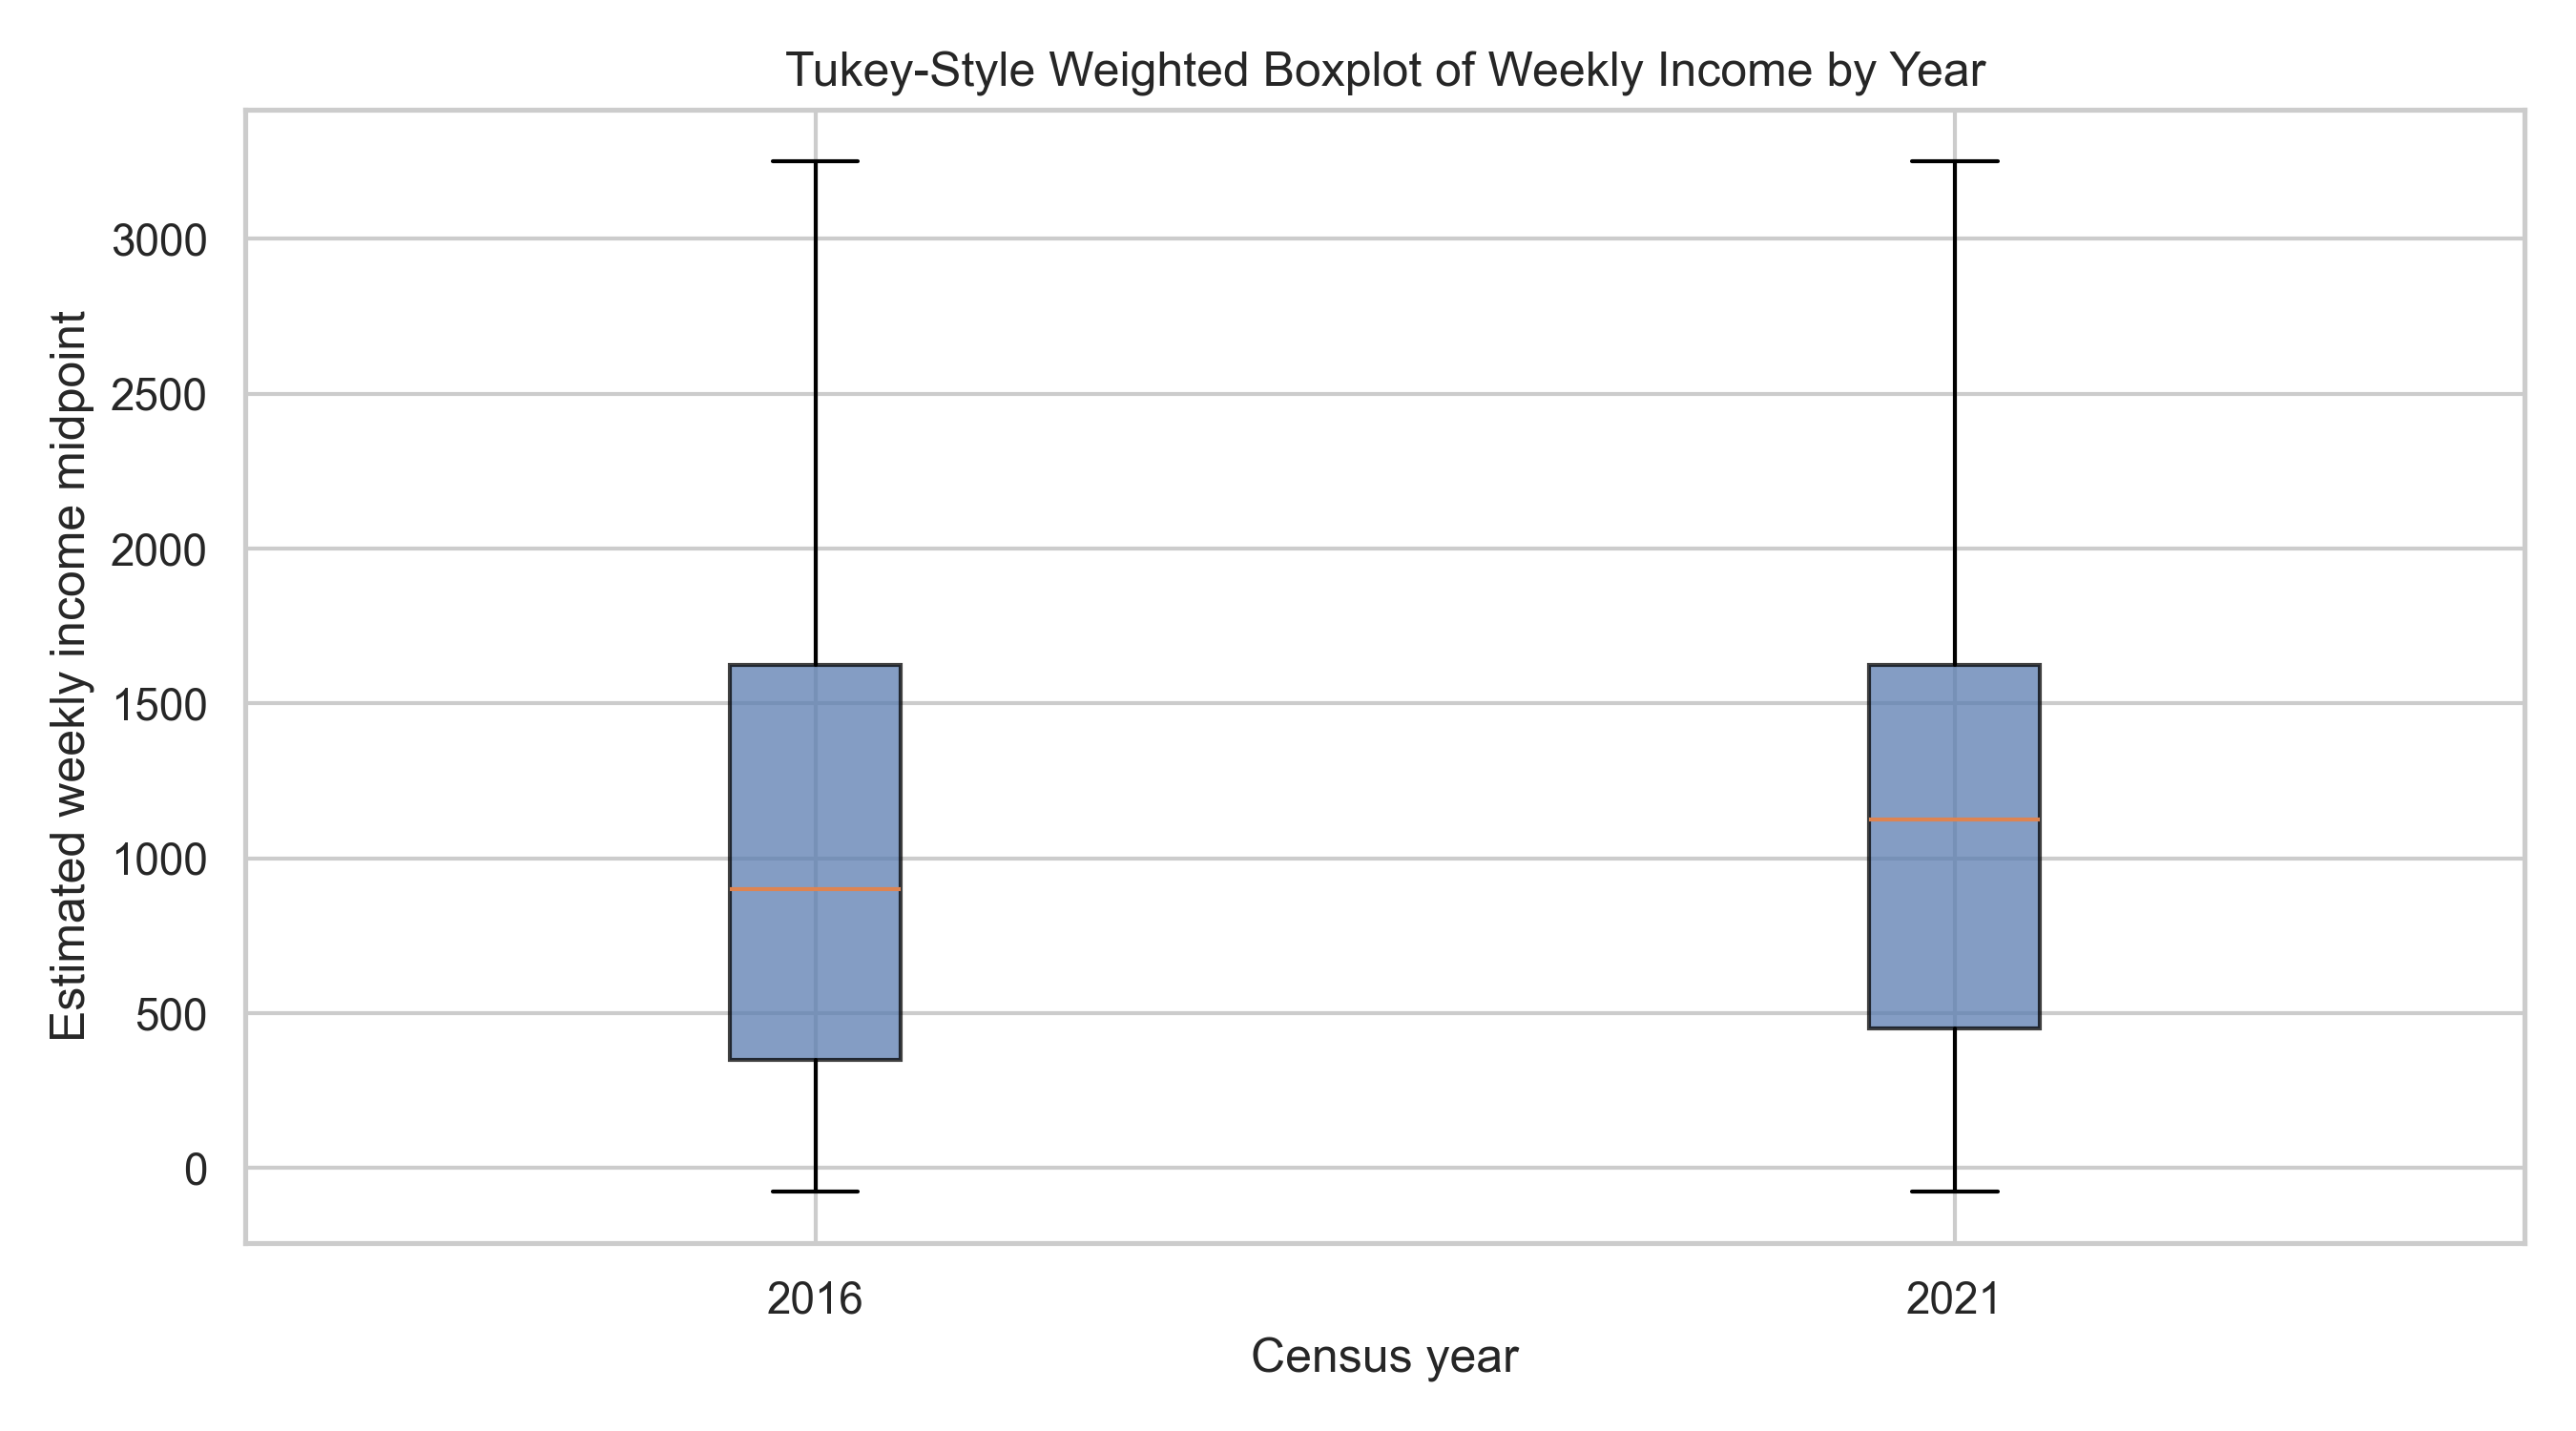

### income_ecdf_by_year.png

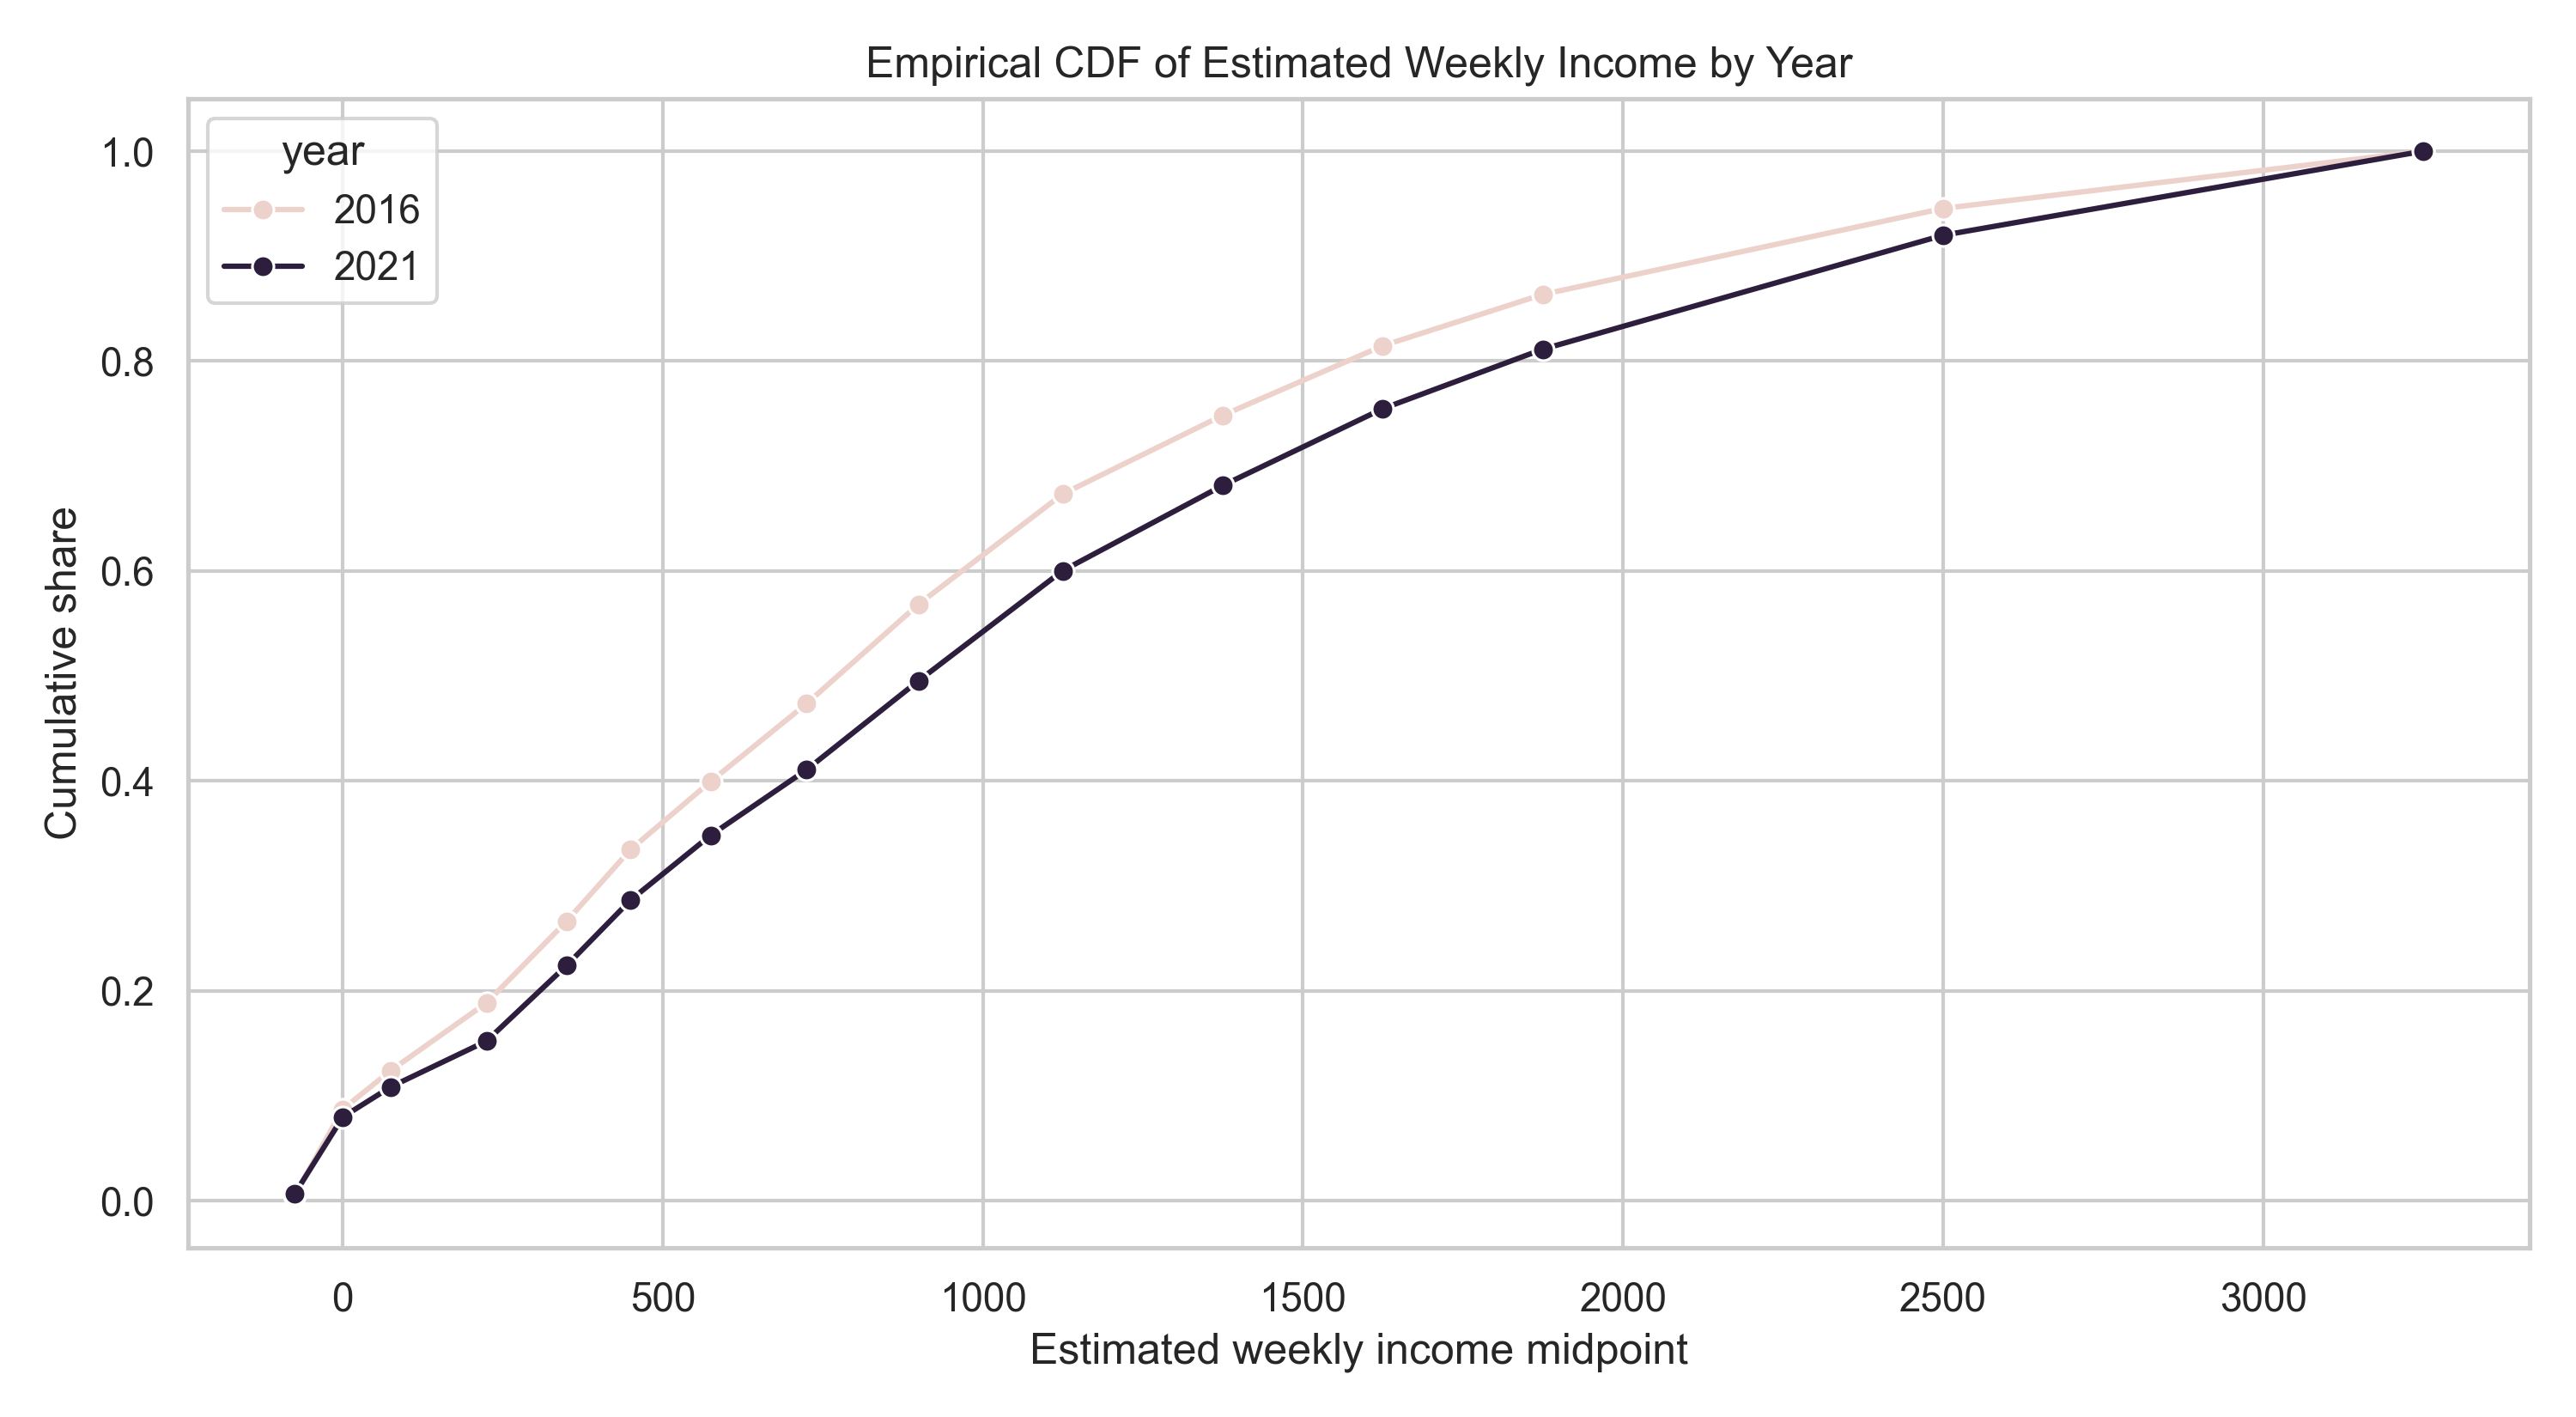

### weighted_mean_income_by_education.png

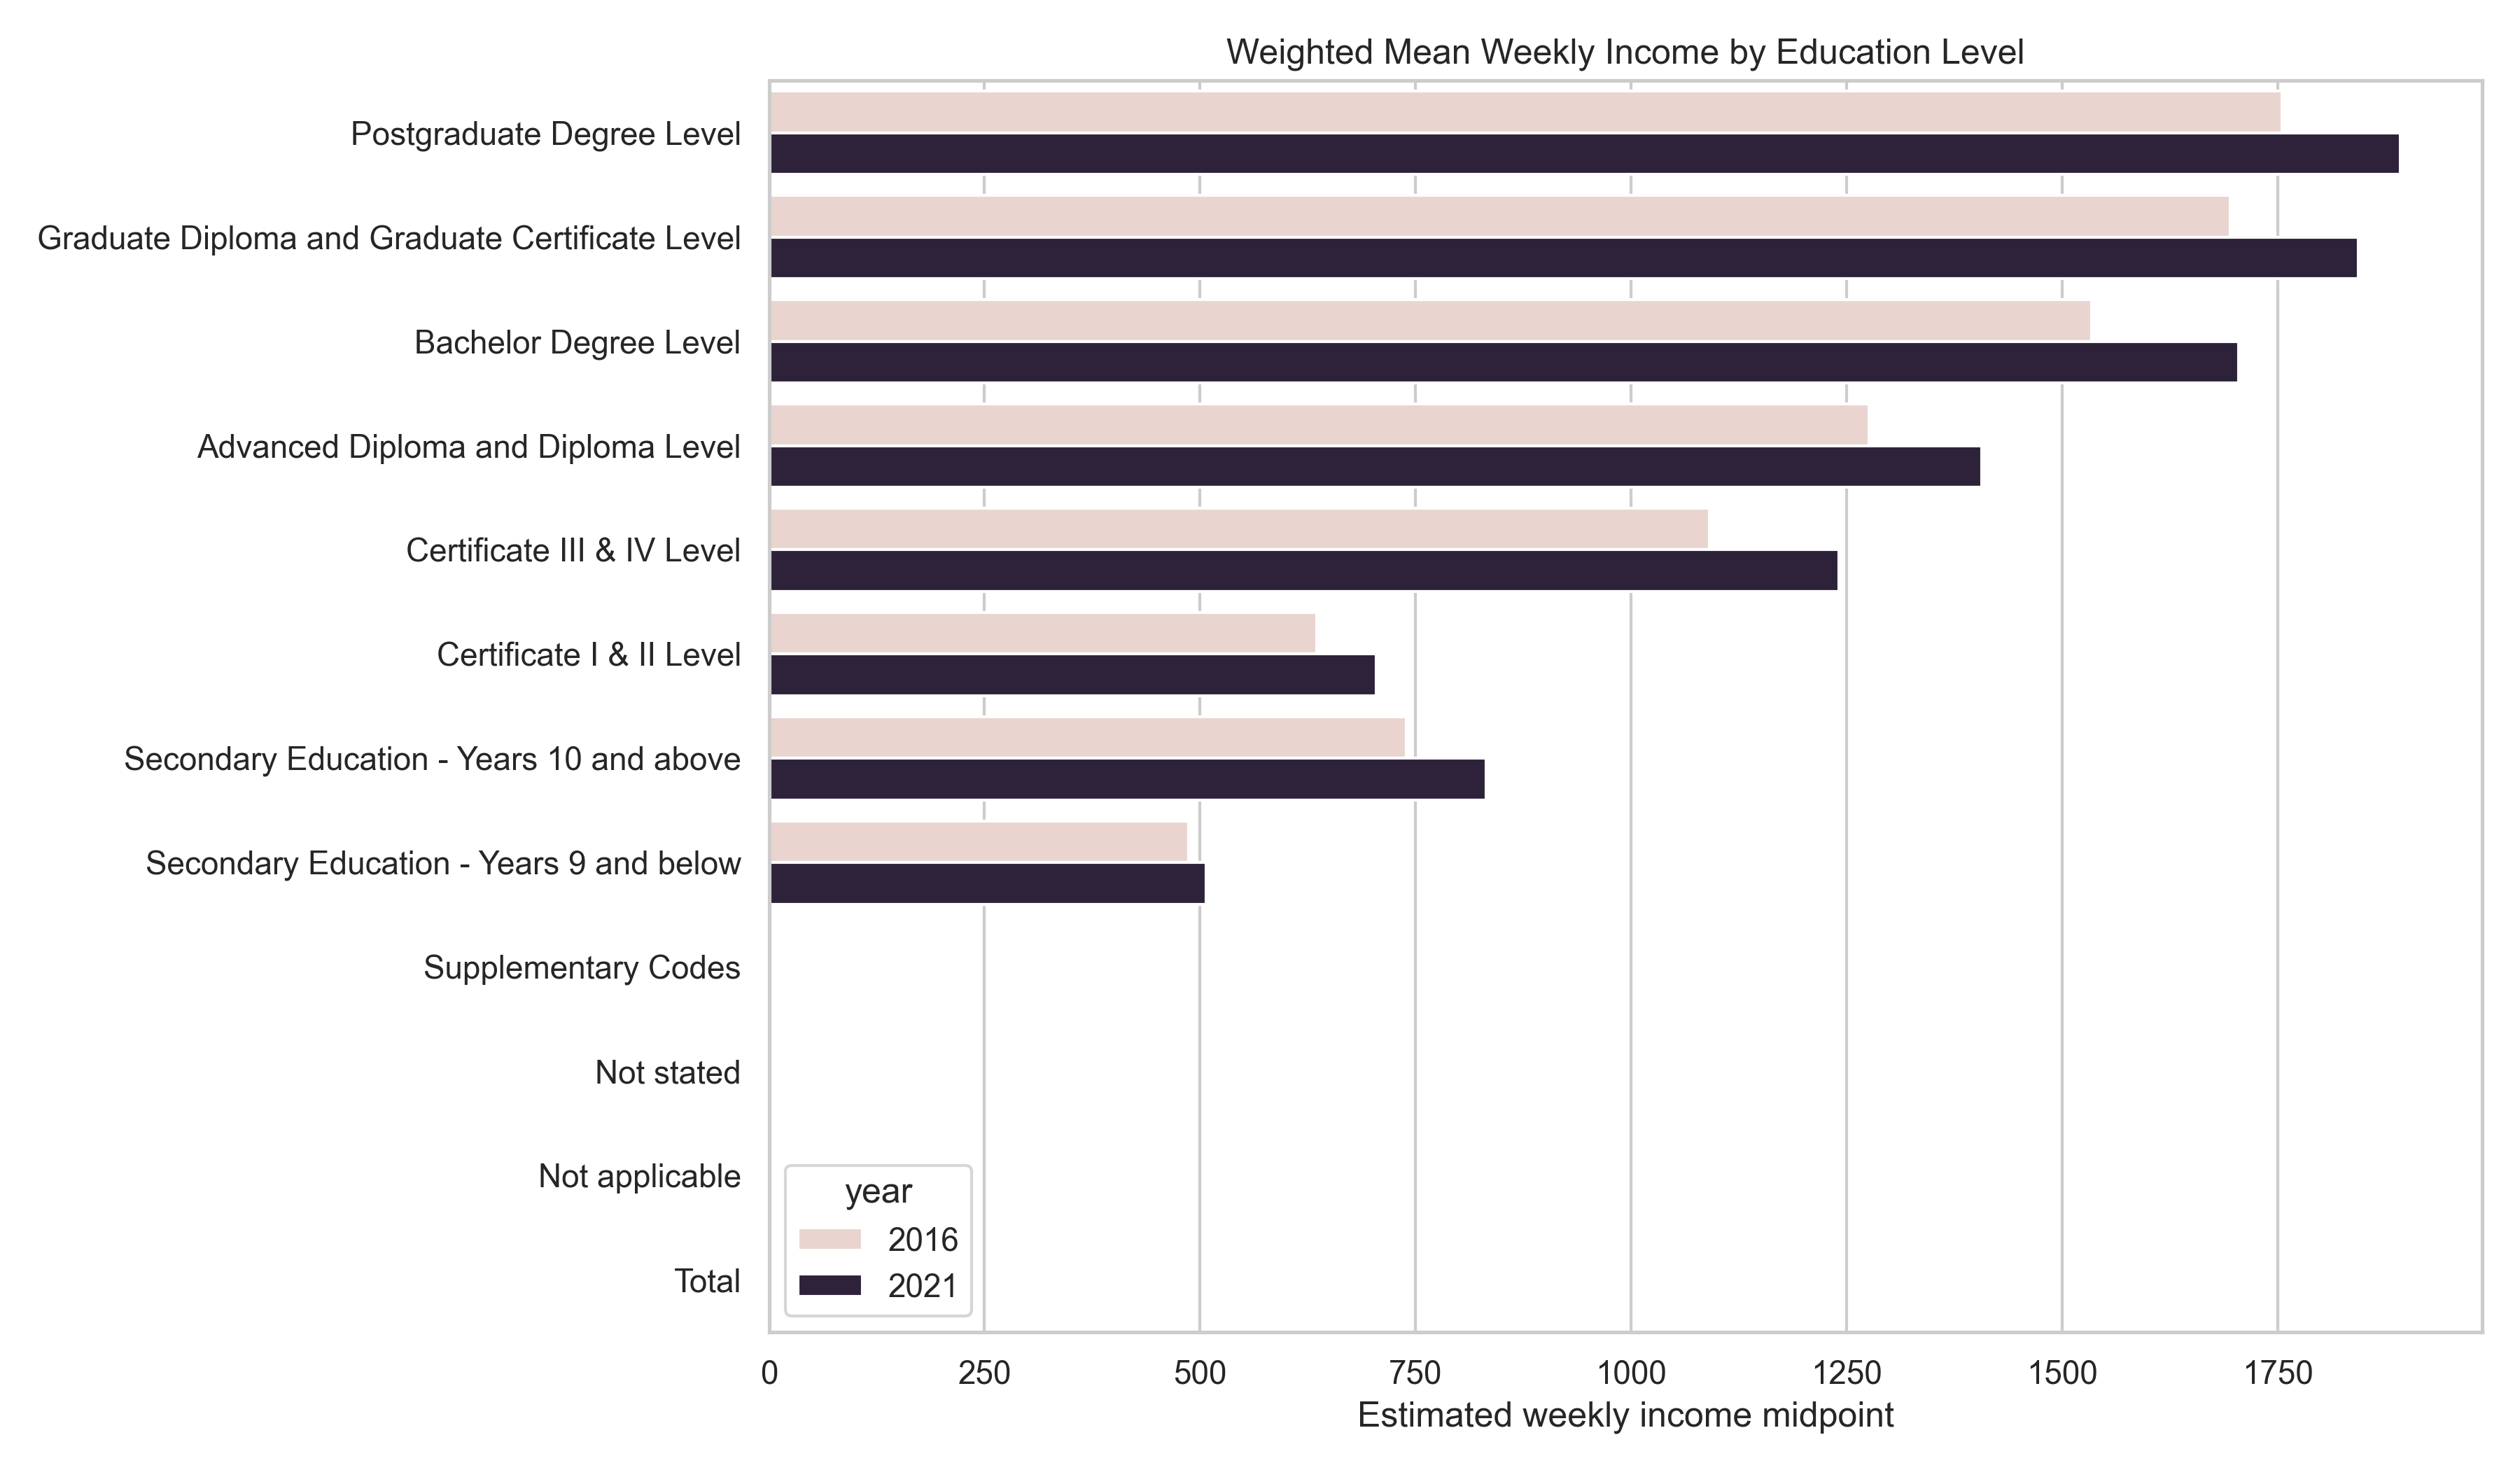

### first_order_effect_education_income.png

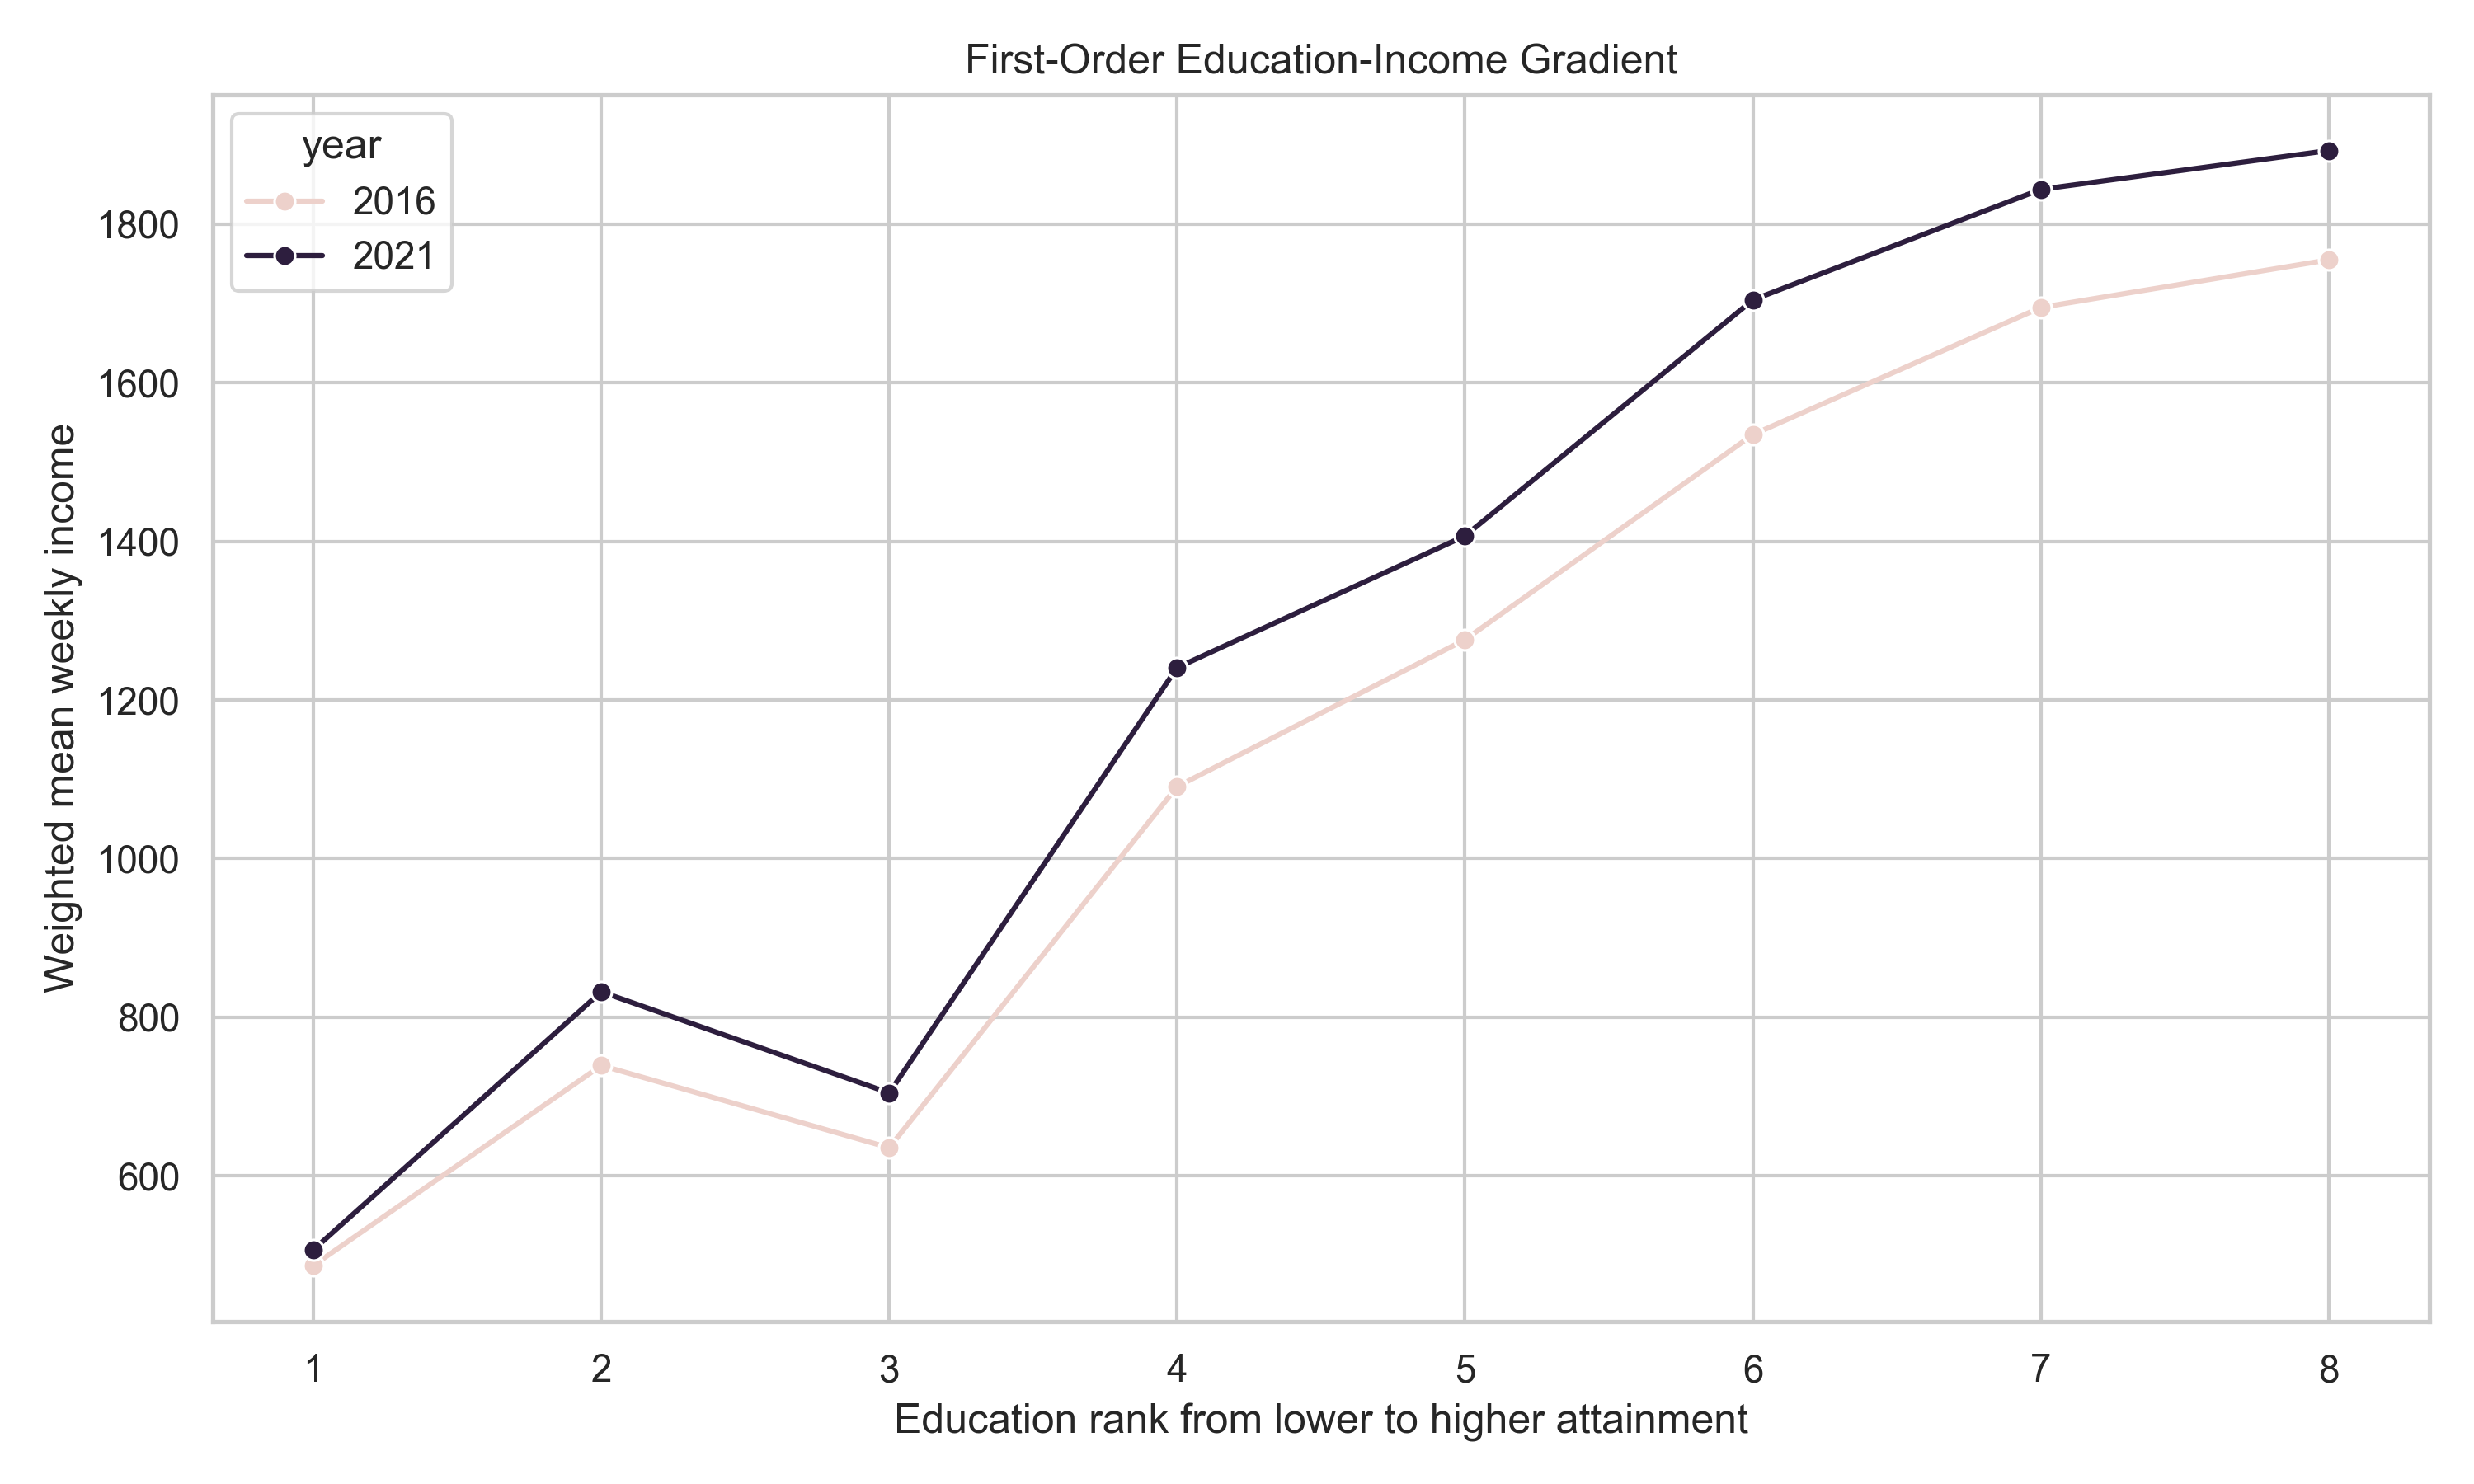

### income_distribution_heatmap_2016.png

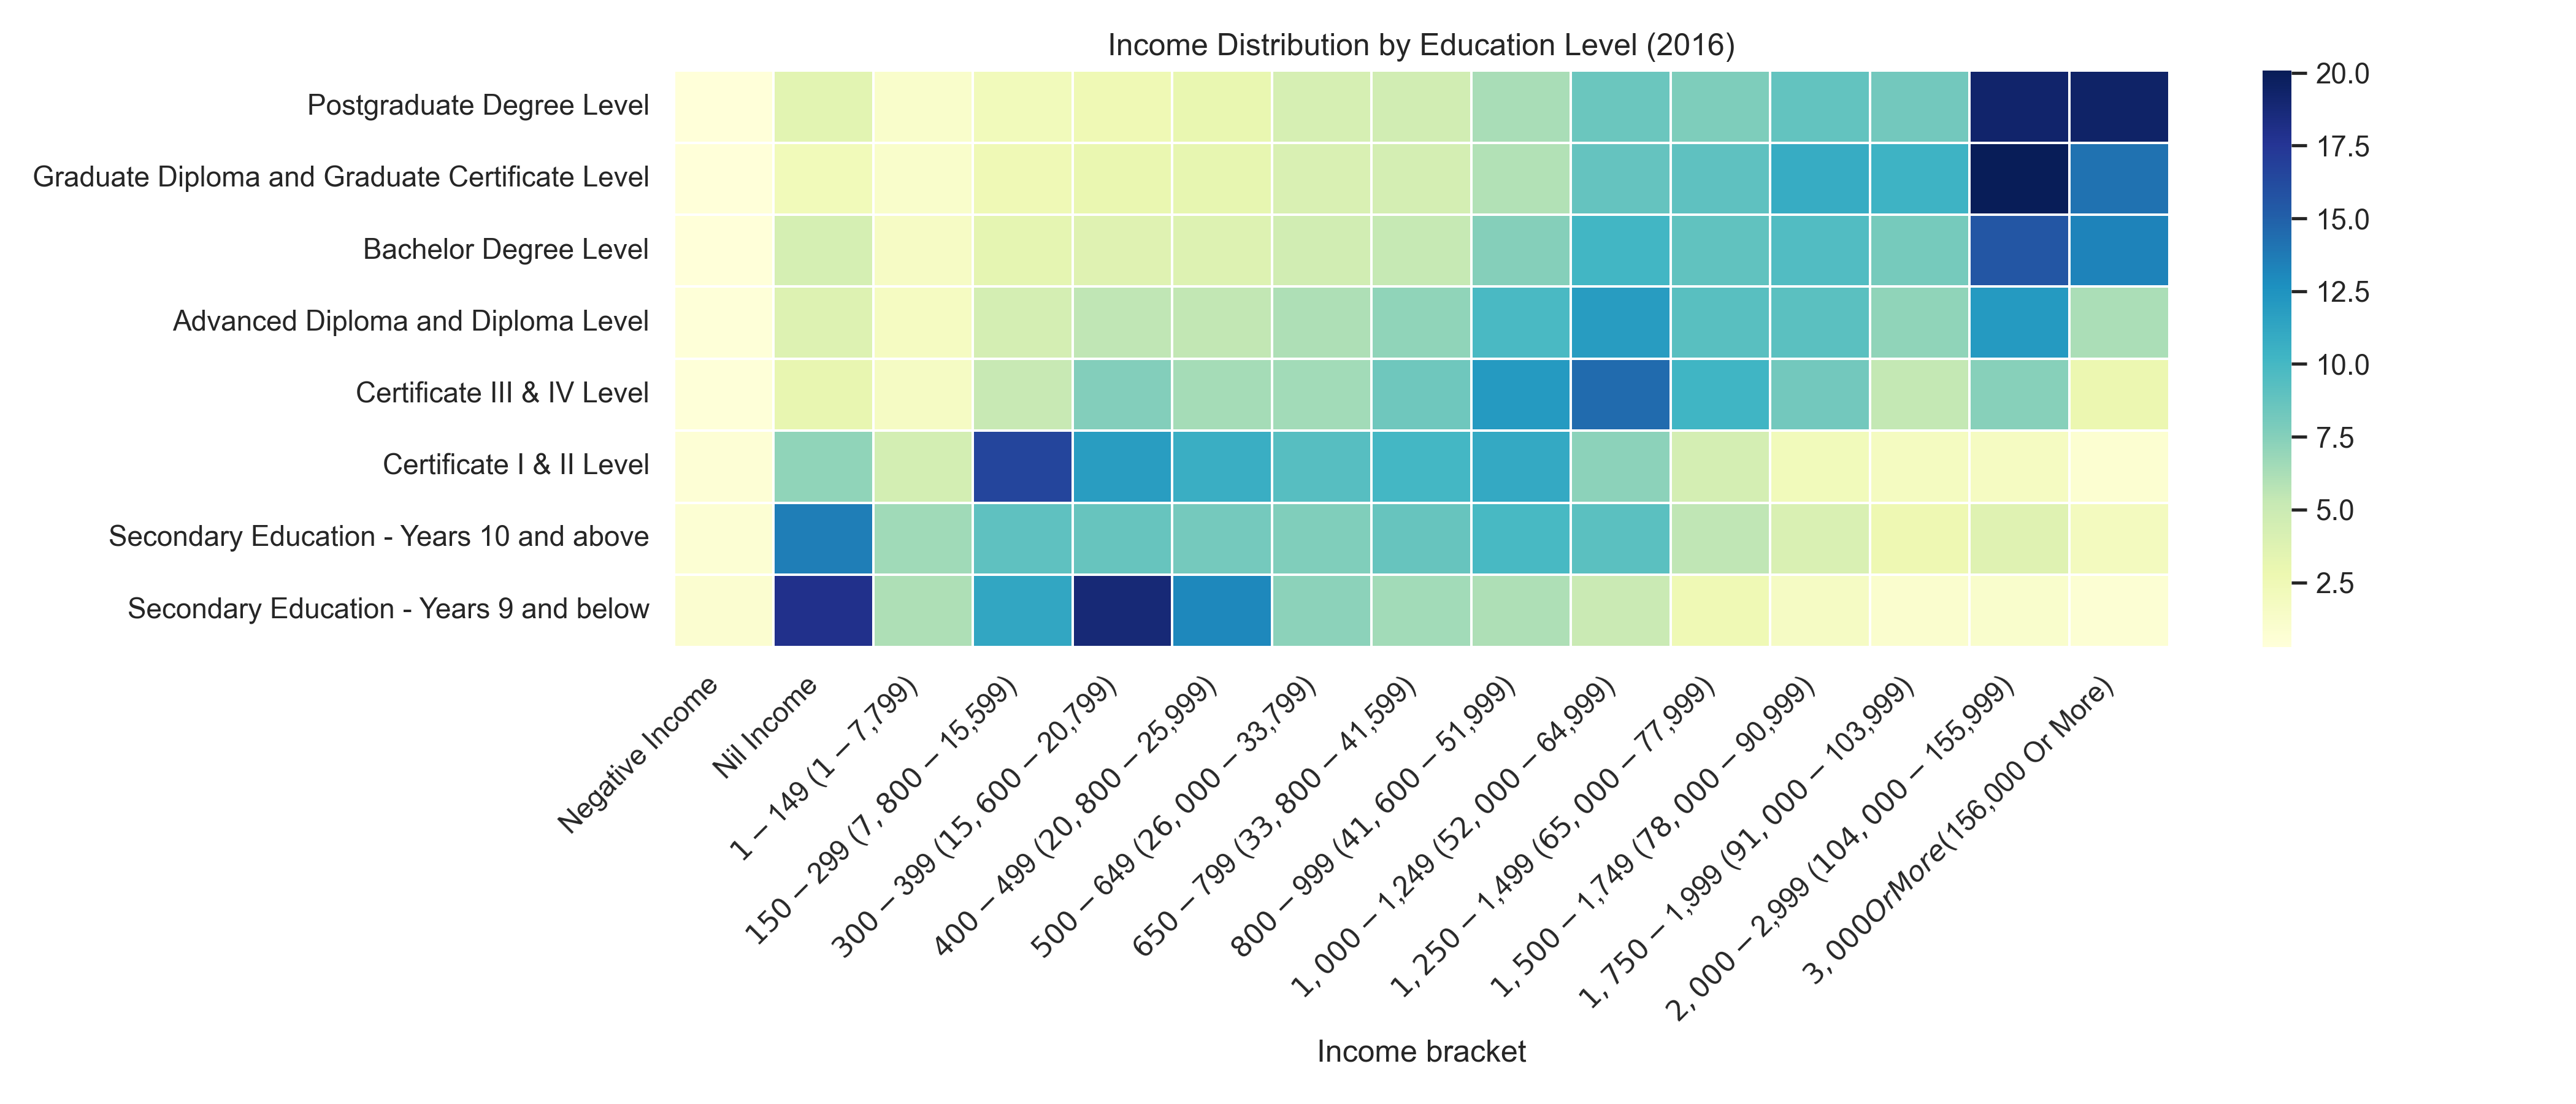

### income_distribution_heatmap_2021.png

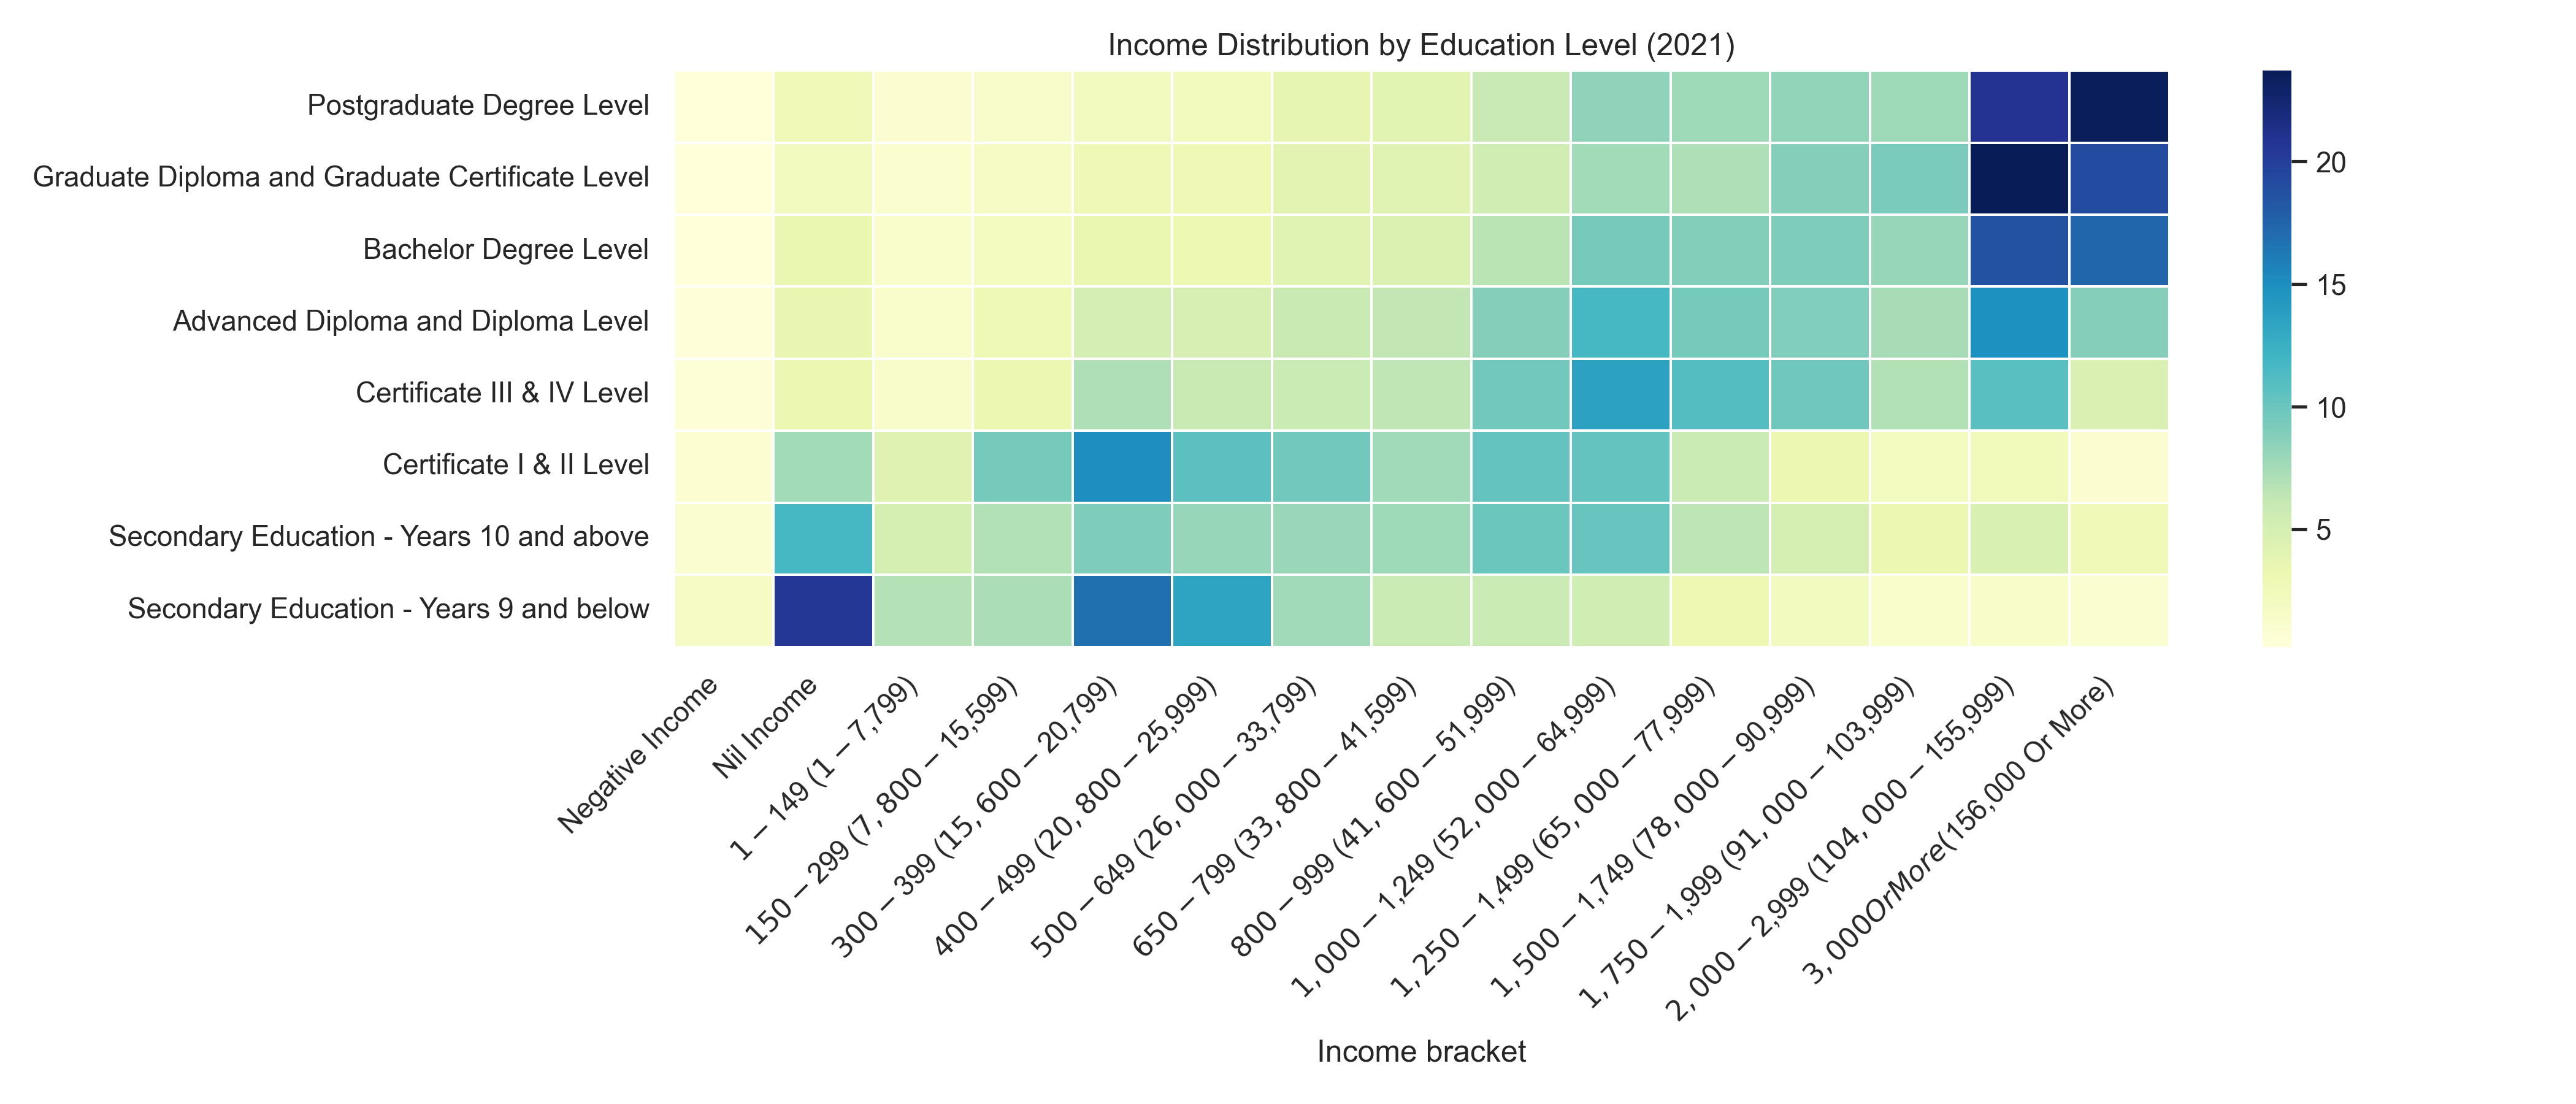

### income_distribution_change_heatmap.png

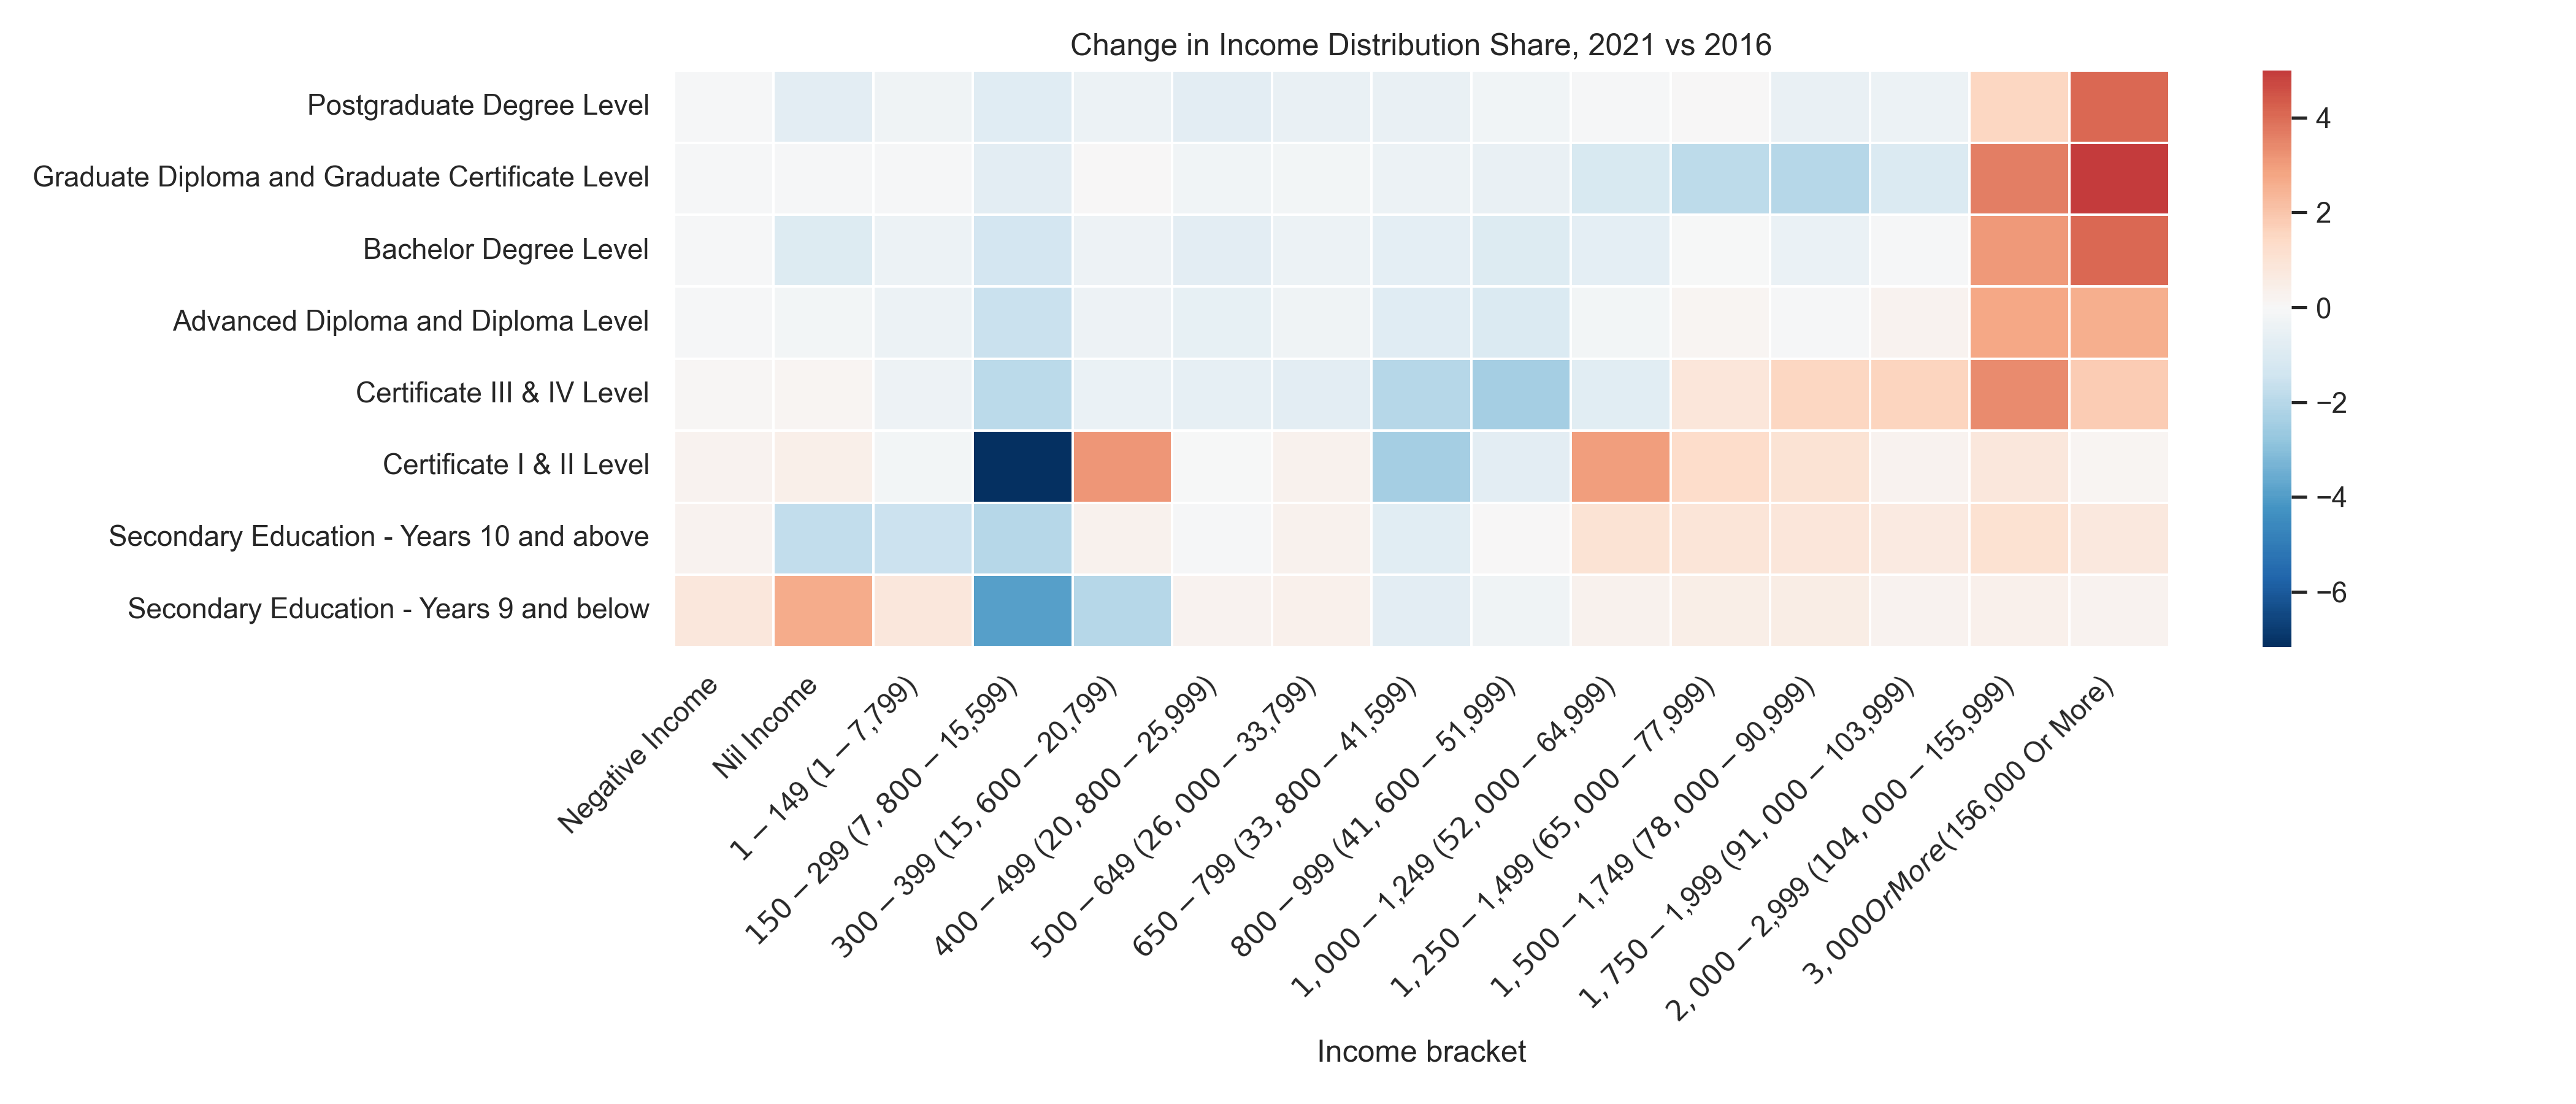

### top_income_share_by_education.png

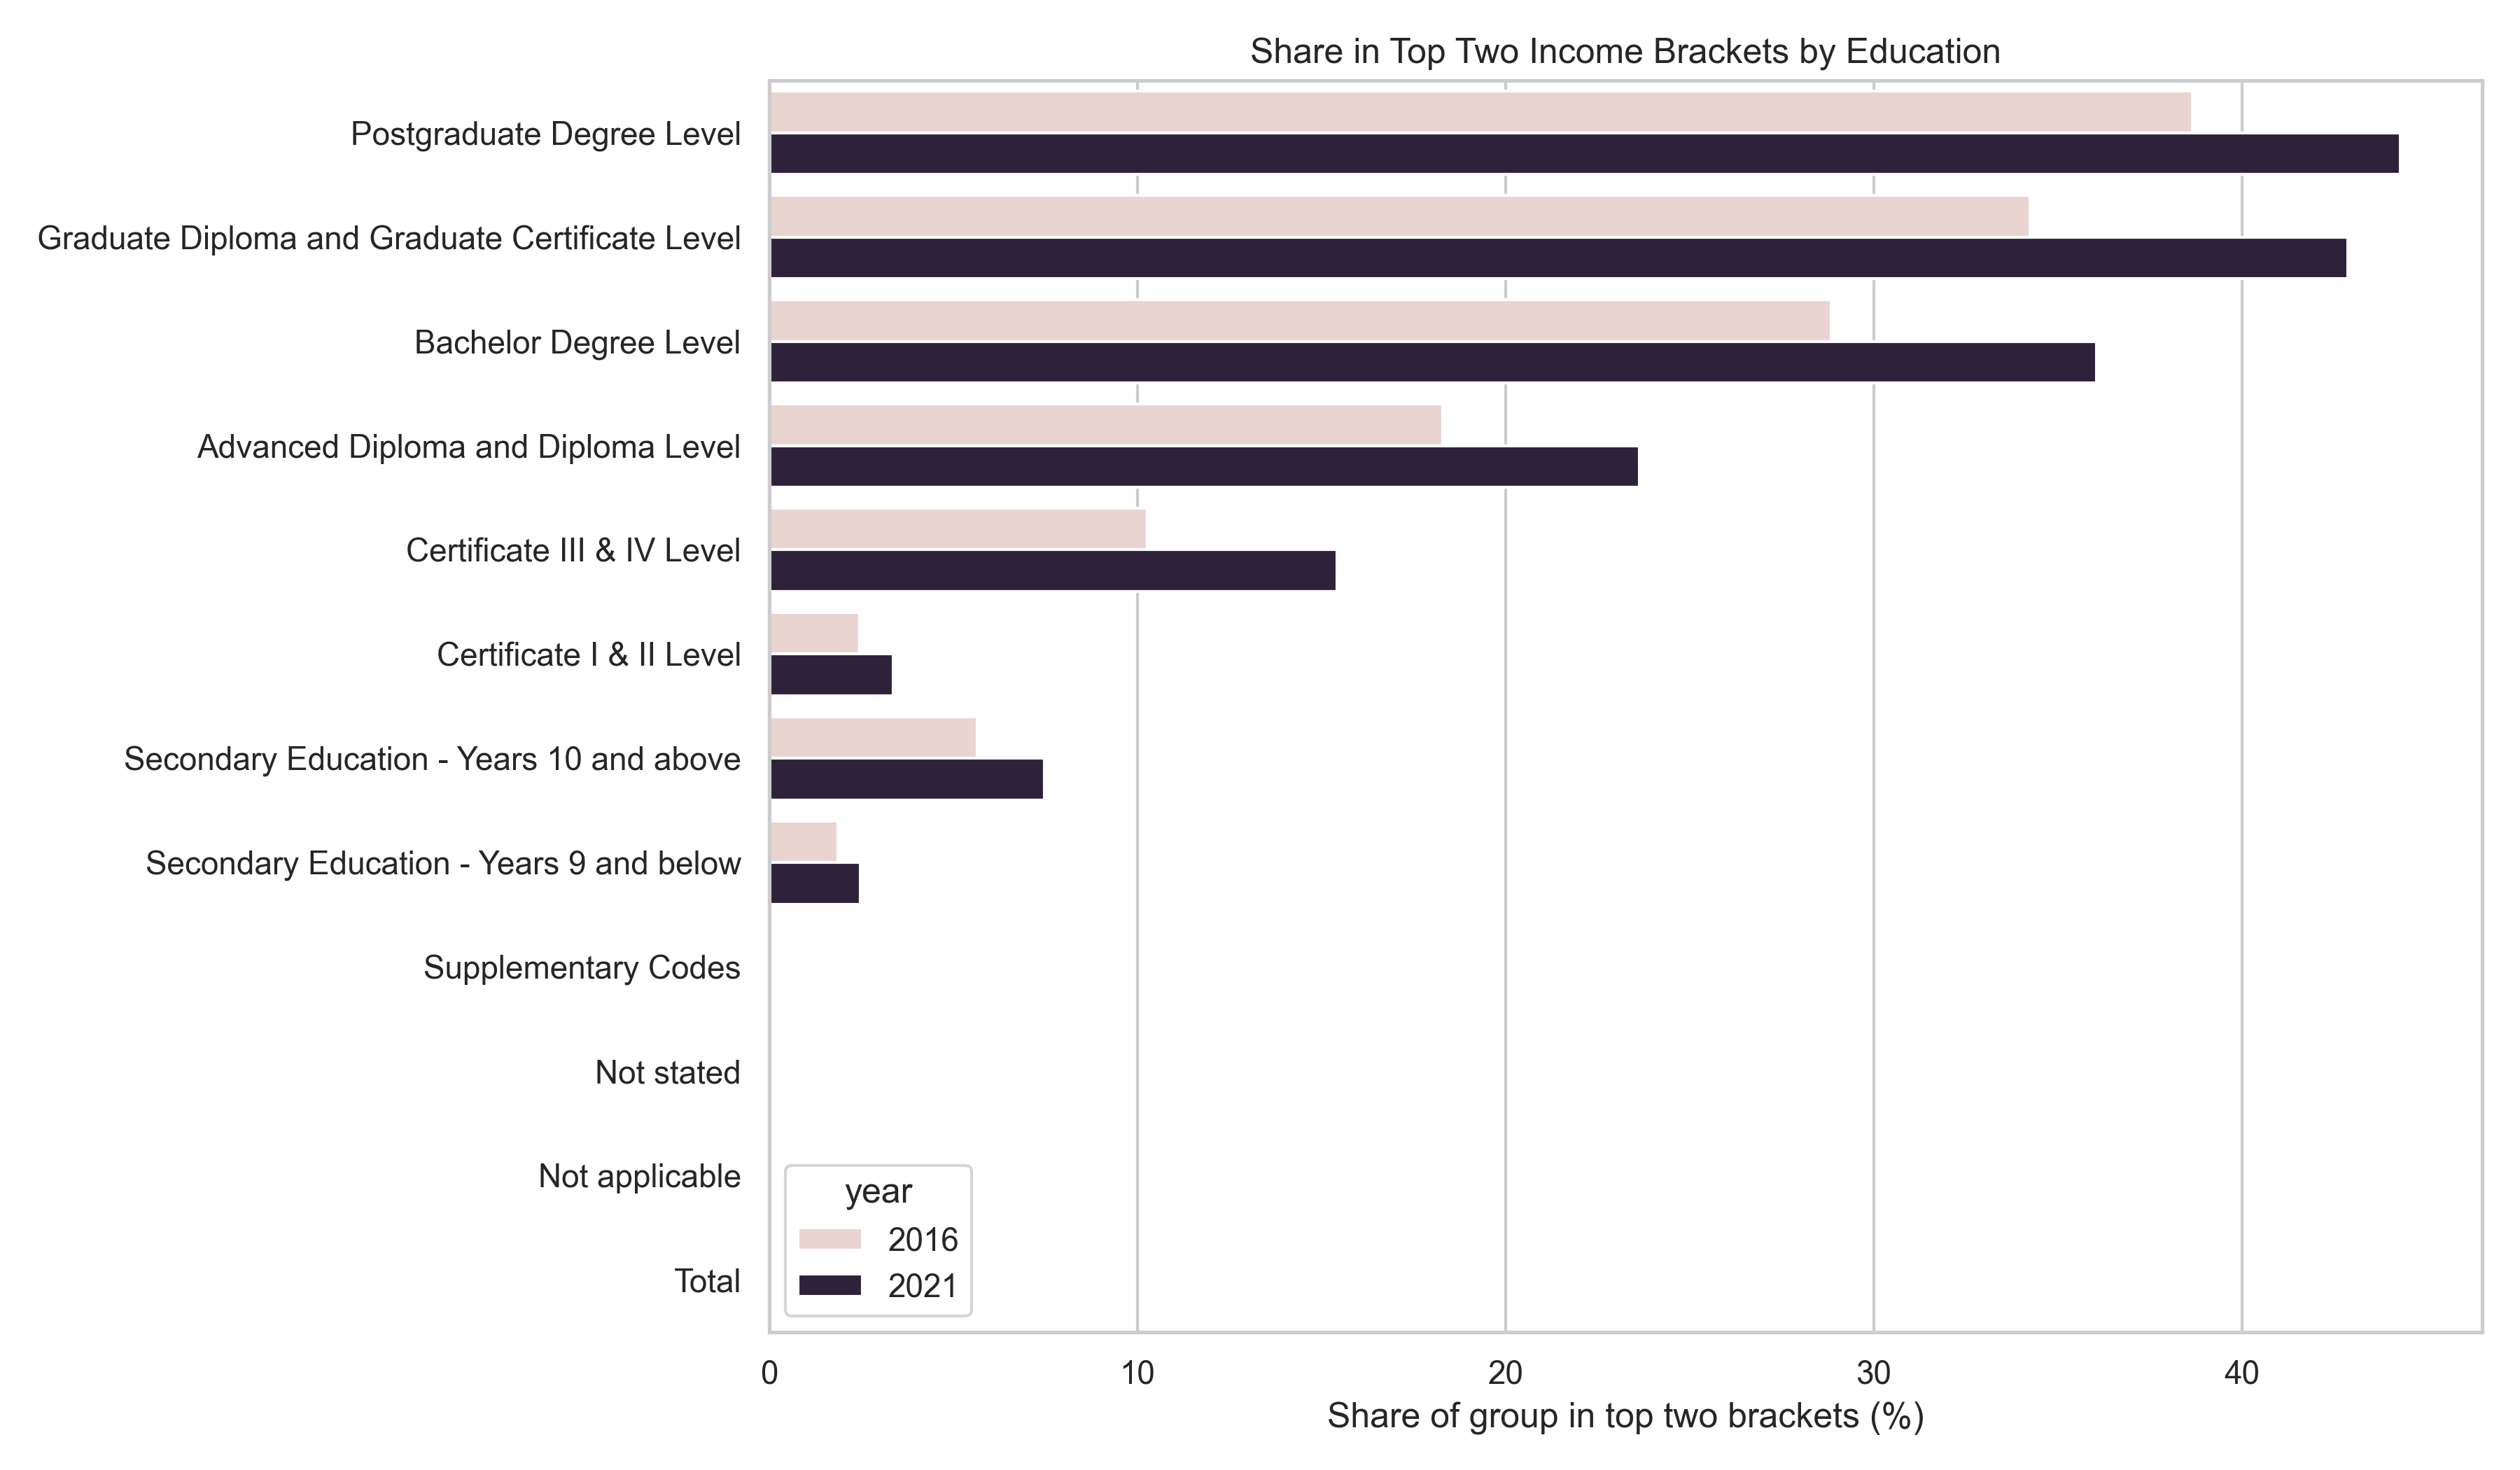

In [19]:
figure_files = [
    'weighted_income_boxplot_by_year.png',
    'income_ecdf_by_year.png',
    'weighted_mean_income_by_education.png',
    'first_order_effect_education_income.png',
    'income_distribution_heatmap_2016.png',
    'income_distribution_heatmap_2021.png',
    'income_distribution_change_heatmap.png',
    'top_income_share_by_education.png',
]

for figure_name in figure_files:
    display(Markdown(f'### {figure_name}'))
    display(Image(filename=str(figures_dir / figure_name)))


## Reproducibility

If needed, the full EDA can be regenerated from the project script below.

In [20]:
# Uncomment to rerun the full analysis from the notebook.
# %run ../../src/04_eda.py